In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("./card_transdata.csv")

In [3]:
df.head()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,57.877857,0.311140,1.945940,1.0,1.0,0.0,0.0,0.0
1,10.829943,0.175592,1.294219,1.0,0.0,0.0,0.0,0.0
2,5.091079,0.805153,0.427715,1.0,0.0,0.0,1.0,0.0
3,2.247564,5.600044,0.362663,1.0,1.0,0.0,1.0,0.0
4,44.190936,0.566486,2.222767,1.0,1.0,0.0,1.0,0.0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 8 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   distance_from_home              1000000 non-null  float64
 1   distance_from_last_transaction  1000000 non-null  float64
 2   ratio_to_median_purchase_price  1000000 non-null  float64
 3   repeat_retailer                 1000000 non-null  float64
 4   used_chip                       1000000 non-null  float64
 5   used_pin_number                 1000000 non-null  float64
 6   online_order                    1000000 non-null  float64
 7   fraud                           1000000 non-null  float64
dtypes: float64(8)
memory usage: 61.0 MB


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
distance_from_home,1000000.0,26.628792,65.390784,0.004874,3.878008,9.967760,25.743985,10632.723672
distance_from_last_transaction,1000000.0,5.036519,25.843093,0.000118,0.296671,0.998650,3.355748,11851.104565
ratio_to_median_purchase_price,1000000.0,1.824182,2.799589,0.004399,0.475673,0.997717,2.096370,267.802942
repeat_retailer,1000000.0,0.881536,0.323157,0.000000,1.000000,1.000000,1.000000,1.000000
used_chip,1000000.0,0.350399,0.477095,0.000000,0.000000,0.000000,1.000000,1.000000
used_pin_number,1000000.0,0.100608,0.300809,0.000000,0.000000,0.000000,0.000000,1.000000
online_order,1000000.0,0.650552,0.476796,0.000000,0.000000,1.000000,1.000000,1.000000
fraud,1000000.0,0.087403,0.282425,0.000000,0.000000,0.000000,0.000000,1.000000


In [7]:
# Count fraud and non-fraud
print(df["fraud"].value_counts())

# Percentage fraud and non-fraud
print(df["fraud"].value_counts(normalize=True) * 100)

fraud
0.0    912597
1.0     87403
Name: count, dtype: int64
fraud
0.0    91.2597
1.0     8.7403
Name: proportion, dtype: float64


In [8]:
df.isnull().sum()

distance_from_home                0
distance_from_last_transaction    0
ratio_to_median_purchase_price    0
repeat_retailer                   0
used_chip                         0
used_pin_number                   0
online_order                      0
fraud                             0
dtype: int64

In [9]:
df.sample(5)

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
437847,6.763447,1.764812,0.438075,1.0,0.0,0.0,1.0,0.0
955334,6.658331,1.015346,0.097596,1.0,0.0,0.0,0.0,0.0
121492,7.652390,0.277616,0.986120,1.0,1.0,0.0,0.0,0.0
183673,2.017892,0.554004,1.568145,1.0,0.0,0.0,1.0,0.0
273686,11.279539,14.020714,0.218487,1.0,1.0,0.0,1.0,0.0


In [10]:
df.corr().T

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
distance_from_home,1.000000,0.000193,-0.001374,0.143124,-0.000697,-0.001622,-0.001301,0.187571
distance_from_last_transaction,0.000193,1.000000,0.001013,-0.000928,0.002055,-0.000899,0.000141,0.091917
ratio_to_median_purchase_price,-0.001374,0.001013,1.000000,0.001374,0.000587,0.000942,-0.000330,0.462305
repeat_retailer,0.143124,-0.000928,0.001374,1.000000,-0.001345,-0.000417,-0.000532,-0.001357
used_chip,-0.000697,0.002055,0.000587,-0.001345,1.000000,-0.001393,-0.000219,-0.060975
used_pin_number,-0.001622,-0.000899,0.000942,-0.000417,-0.001393,1.000000,-0.000291,-0.100293
online_order,-0.001301,0.000141,-0.000330,-0.000532,-0.000219,-0.000291,1.000000,0.191973
fraud,0.187571,0.091917,0.462305,-0.001357,-0.060975,-0.100293,0.191973,1.000000


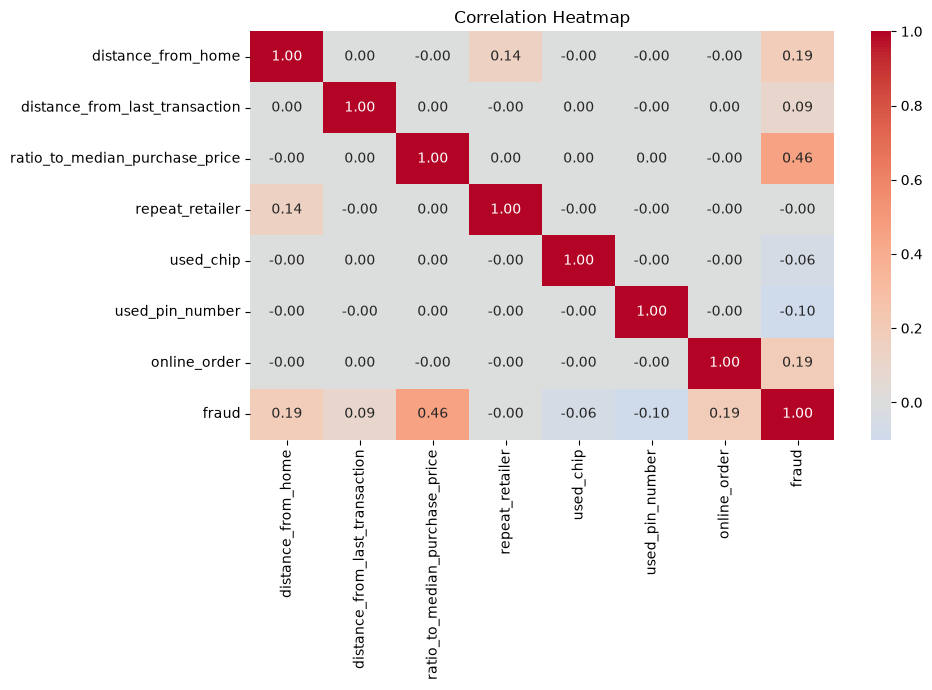

In [11]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

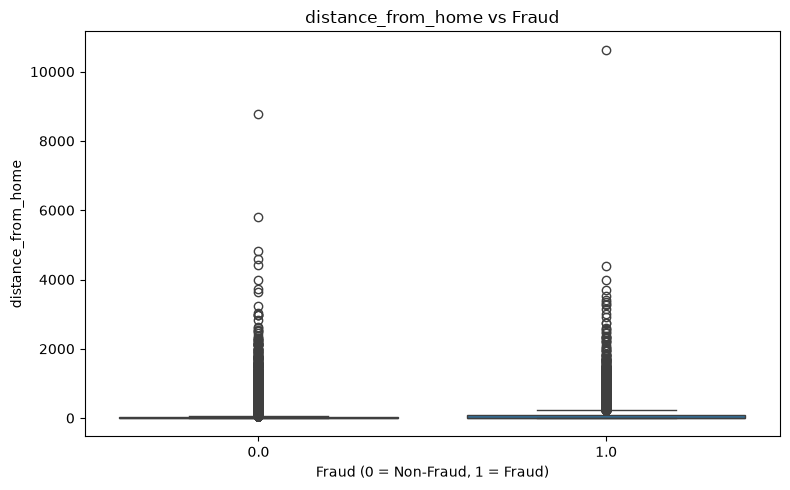

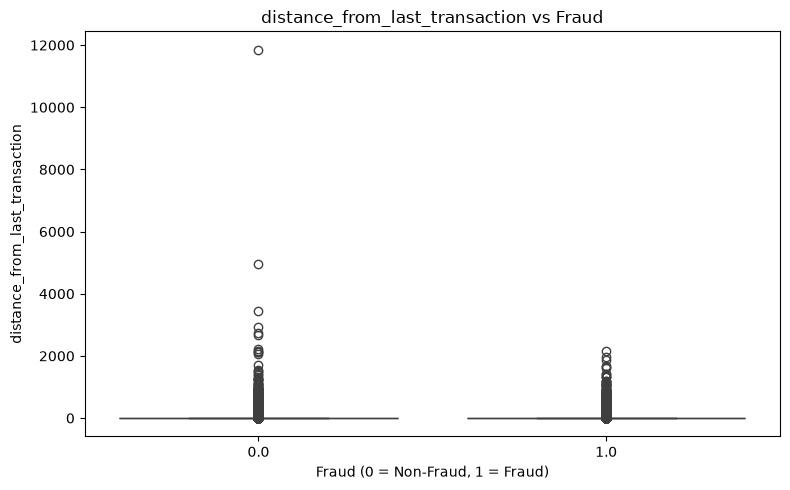

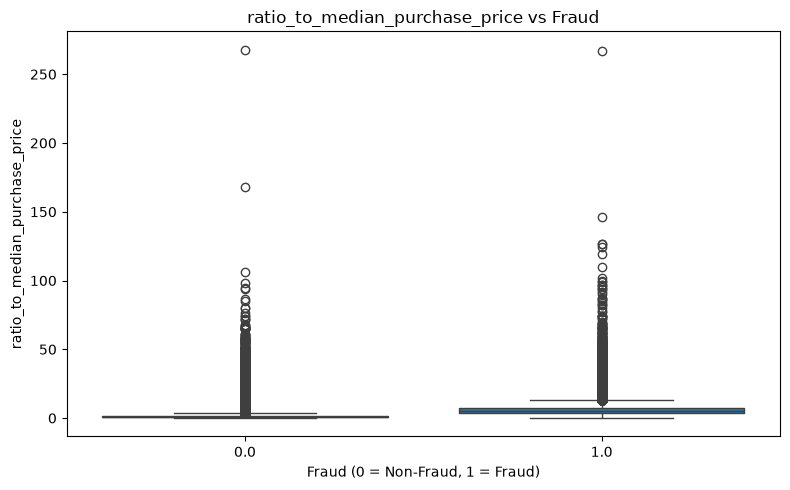

In [12]:
features = [
    "distance_from_home",
    "distance_from_last_transaction",
    "ratio_to_median_purchase_price"
]

for feature in features:

    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=df,
        x="fraud",
        y=feature
    )

    plt.title(f"{feature} vs Fraud")
    plt.xlabel("Fraud (0 = Non-Fraud, 1 = Fraud)")
    plt.ylabel(feature)

    plt.tight_layout()
    plt.show()

In [13]:
plot_sample = df.sample(
    n=10000,
    random_state=42
)

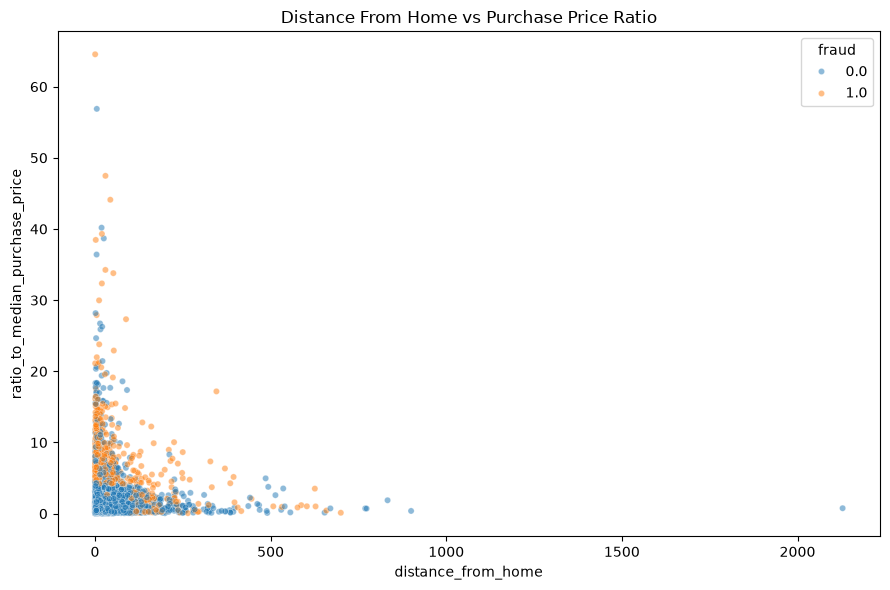

In [14]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=plot_sample,
    x="distance_from_home",
    y="ratio_to_median_purchase_price",
    hue="fraud",
    alpha=0.5,
    s=20
)

plt.title("Distance From Home vs Purchase Price Ratio")
plt.tight_layout()
plt.show()

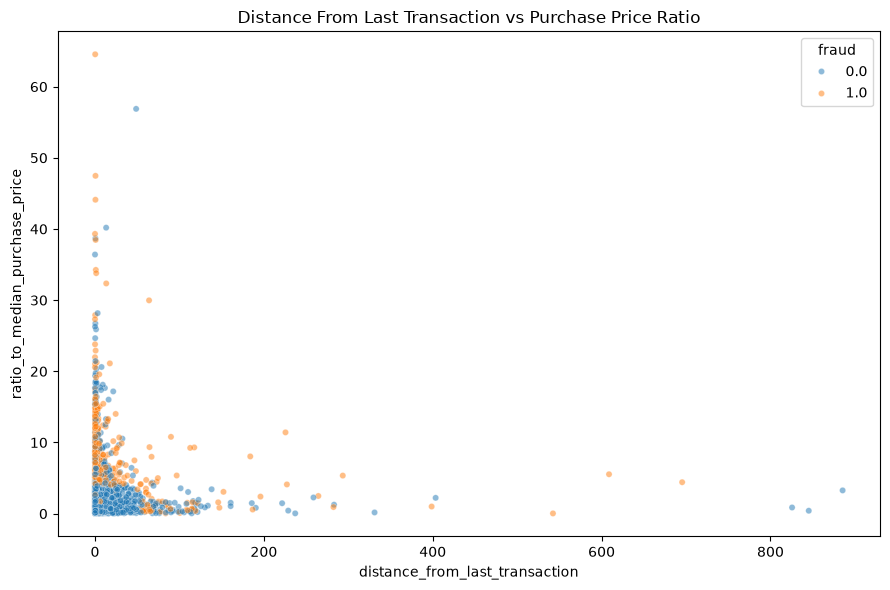

In [15]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=plot_sample,
    x="distance_from_last_transaction",
    y="ratio_to_median_purchase_price",
    hue="fraud",
    alpha=0.5,
    s=20
)

plt.title("Distance From Last Transaction vs Purchase Price Ratio")
plt.tight_layout()
plt.show()

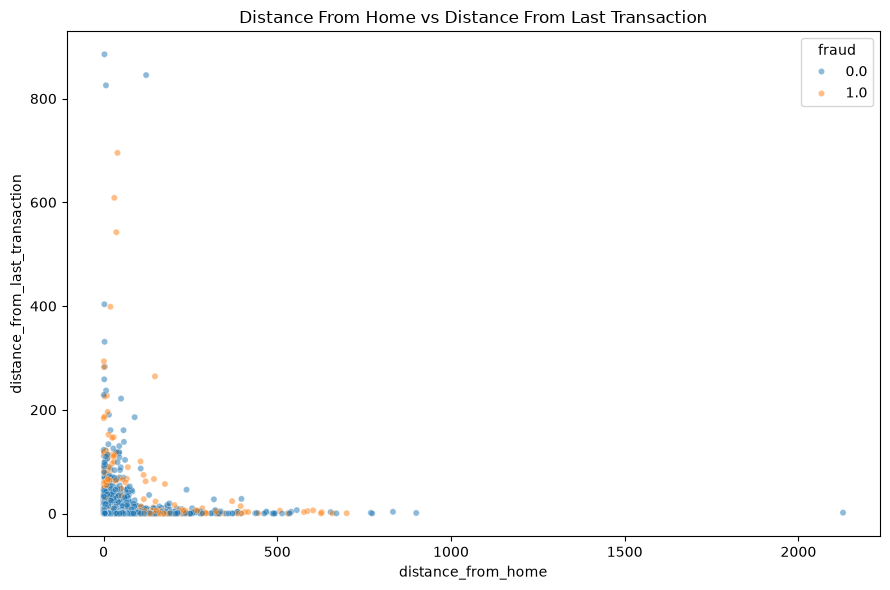

In [16]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=plot_sample,
    x="distance_from_home",
    y="distance_from_last_transaction",
    hue="fraud",
    alpha=0.5,
    s=20
)

plt.title("Distance From Home vs Distance From Last Transaction")
plt.tight_layout()
plt.show()

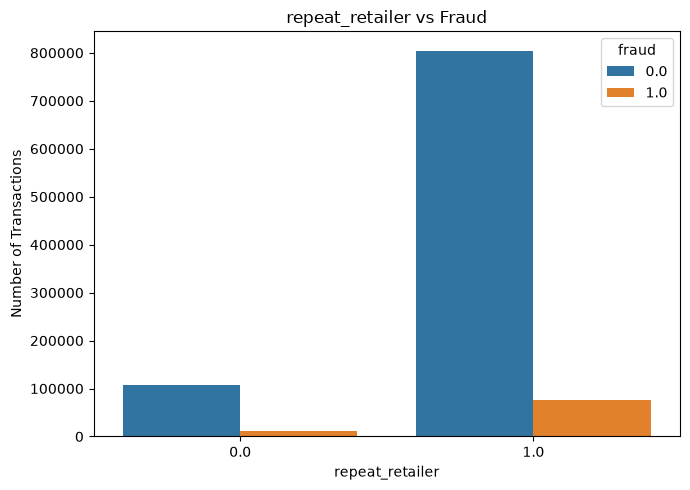

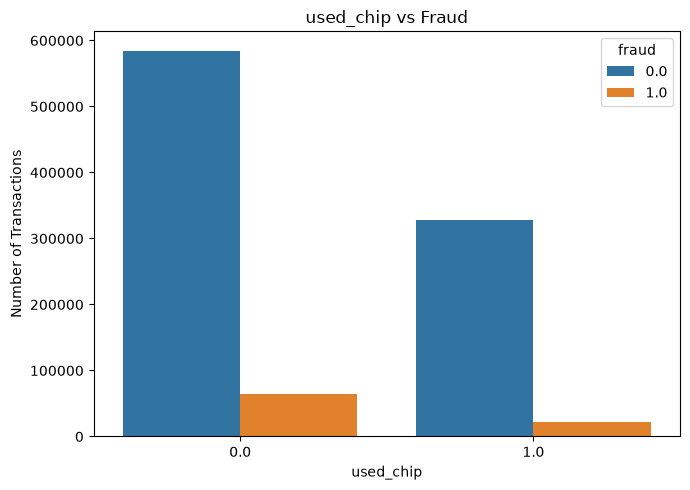

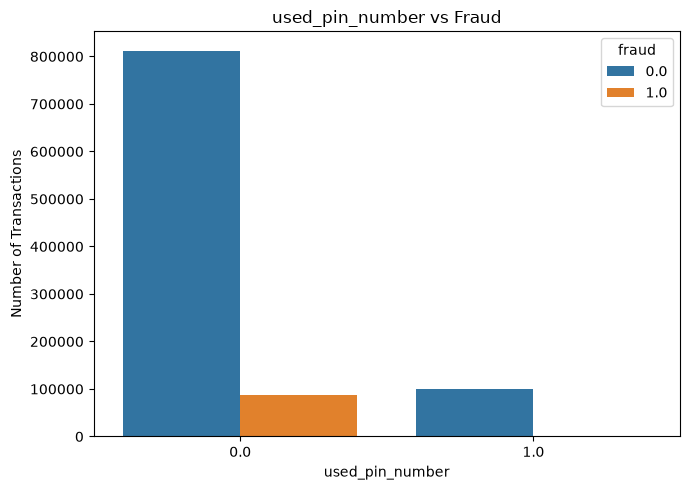

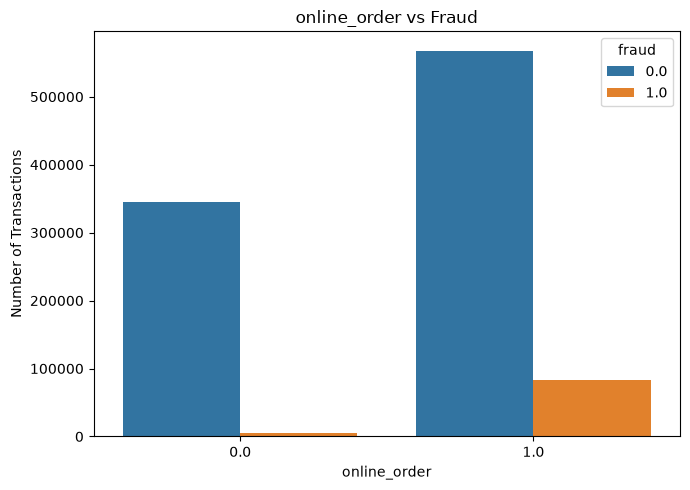

In [17]:
binary_features = [
    "repeat_retailer",
    "used_chip",
    "used_pin_number",
    "online_order"
]

for feature in binary_features:

    plt.figure(figsize=(7, 5))

    sns.countplot(
        data=df,
        x=feature,
        hue="fraud"
    )

    plt.title(f"{feature} vs Fraud")
    plt.xlabel(feature)
    plt.ylabel("Number of Transactions")

    plt.tight_layout()
    plt.show()

In [19]:
df.columns

Index(['distance_from_home', 'distance_from_last_transaction',
       'ratio_to_median_purchase_price', 'repeat_retailer', 'used_chip',
       'used_pin_number', 'online_order', 'fraud'],
      dtype='str')

In [20]:
X = df.drop(columns=["fraud"])
y = df["fraud"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1000000, 7)
y shape: (1000000,)
